# CS 301 Milestone 2 Technical Roadmap  
## NYC Evictions and Borough Demographics

**Project question:** How do housing demographics across New York City boroughs relate to eviction patterns?

**Milestone 1 hypotheses**
- Null hypothesis (H0): Evictions and housing demographics are not correlated.
- Alternative hypothesis (H1): Evictions and housing demographics are directly correlated.


## 0. Setup and Data Loading

Upload these two files into the Colab session before running all cells:

- `Evictions_20260428.csv`
- `demo_2016acs5yr_nyc.xlsx`

The notebook includes a fallback uploader for Google Colab. If the files are already in the working directory, it will load them directly.


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [19]:
from google.colab import drive
drive.mount('/content/drive')

evictions_file = "/content/drive/MyDrive/CS301_Milestone2/Evictions_20260428.csv"
demo_file = "/content/drive/MyDrive/CS301_Milestone2/demo_2016acs5yr_nyc.xlsx"

evictions = pd.read_csv(evictions_file, low_memory=False)
demo_raw = pd.read_excel(demo_file, header=None)

print("Evictions shape:", evictions.shape)
print("Demographics shape:", demo_raw.shape)

display(evictions.head())
display(demo_raw.head(8))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Evictions shape: (127013, 20)
Demographics shape: (123, 26)


,Court Index Number,Docket Number,Eviction Address,Eviction Apartment Number,Executed Date,Marshal First Name,Marshal Last Name,Residential/Commercial,BOROUGH,Eviction Postcode,Ejectment,Eviction/Legal Possession,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA
0,312253/22,112935,9602 GLENWOOD ROAD,STORE,07/12/2023,Justin,Grossman,Commercial,BROOKLYN,11236,Not an Ejectment,Possession,40.6447,-73.9030,18.0000,46.0000,968.0000,"3,254,771.0000","3,081,840,033.0000",Canarsie
1,61897/18,92314,450 EAST 184TH ST,4H,03/26/2019,Henry,Daley,Residential,BRONX,10458,Not an Ejectment,Possession,40.8562,-73.8936,6.0000,15.0000,385.0000,"2,011,347.0000","2,030,380,055.0000",Claremont-Bathgate
2,K73930/18,108176,1745 EAST 12TH ST,3H,09/18/2018,Darlene,Barone,Residential,BROOKLYN,11229,Not an Ejectment,Possession,40.6068,-73.9608,15.0000,48.0000,554.0000,"3,182,881.0000","3,067,950,075.0000",Homecrest
3,71525/2018,19904,590 - FLATBUSH AVENUE,16A,08/15/2018,Charles,Marchisotto,Residential,BROOKLYN,11225,Not an Ejectment,Possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,73785/17,6825,449 W 44TH STREET,3K,02/13/2018,Robert,Renzulli,Residential,MANHATTAN,10036,Not an Ejectment,Possession,40.7603,-73.9931,4.0000,3.0000,121.0000,"1,026,426.0000","1,010,540,056.0000",Clinton


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,DP05: ACS DEMOGRAPHIC AND HOUSING ESTIMATES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-2016 American Community Survey 5-Year Est...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Subject,NaN,Bronx,NaN,NaN,NaN,Brooklyn,NaN,NaN,NaN,Manhattan,NaN,NaN,NaN,Queens,NaN,NaN,NaN,Staten Island,NaN,NaN,NaN,New York city,NaN,NaN,NaN
4,NaN,NaN,Estimate,Margin of Error,Percent,Percent Margin of Error,Estimate,Margin of Error,Percent,Percent Margin of Error,Estimate,Margin of Error,Percent,Percent Margin of Error,Estimate,Margin of Error,Percent,Percent Margin of Error,Estimate,Margin of Error,Percent,Percent Margin of Error,Estimate,Margin of Error,Percent,Percent Margin of Error
5,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Total population,NaN,"1,436,785",*****,"1,436,785",(X),"2,606,852",*****,"2,606,852",(X),"1,634,989",*****,"1,634,989",(X),"2,310,011",*****,"2,310,011",(X),"473,324",*****,"473,324",(X),"8,461,961",*****,"8,461,961",(X)
7,Male,NaN,"676,440",+/-215,47.1%,+/-0.1,"1,234,959",+/-139,47.4%,+/-0.1,"773,232",+/-93,47.3%,+/-0.1,"1,120,010",+/-257,48.5%,+/-0.1,"229,095",+/-82,48.4%,+/-0.1,"4,033,736",+/-378,47.7%,+/-0.1


## 1. Data Cleaning and Feature Engineering

The eviction dataset contains individual eviction records. The demographics file is a borough-level ACS profile. To connect them, we standardize borough names, summarize evictions by borough and time, and convert demographic values into numeric features.

Because the demographics data is borough-level rather than household-level, the main modeling unit will be **borough-month**. That gives us repeated eviction observations over time while attaching the same ACS demographic profile to each borough.


In [ ]:
def clean_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = (
            value.replace(",", "")
            .replace("%", "")
            .replace("+/-", "")
            .replace("*****", "")
            .replace("(X)", "")
            .strip()
        )
        if value == "":
            return np.nan
    try:
        return float(value)
    except Exception:
        return np.nan

borough_cols = {
    "Bronx": 2,
    "Brooklyn": 6,
    "Manhattan": 10,
    "Queens": 14,
    "Staten Island": 18
}

demo_rows = []
for borough, col in borough_cols.items():
    demo_rows.append({
        "BOROUGH_CLEAN": borough,
        "total_population": clean_number(demo_raw.iloc[6, col]),
        "female_pct": clean_number(demo_raw.iloc[8, col + 2]),
        "median_age": clean_number(demo_raw.iloc[24, col]),
        "hispanic_pct": clean_number(demo_raw.iloc[83, col + 2]),
        "white_non_hispanic_pct": clean_number(demo_raw.iloc[89, col + 2]),
        "black_non_hispanic_pct": clean_number(demo_raw.iloc[90, col + 2]),
        "asian_non_hispanic_pct": clean_number(demo_raw.iloc[92, col + 2]),
        "housing_units": clean_number(demo_raw.iloc[99, col])
    })

demo = pd.DataFrame(demo_rows)
display(demo)

,BOROUGH_CLEAN,total_population,female_pct,median_age,hispanic_pct,white_non_hispanic_pct,black_non_hispanic_pct,asian_non_hispanic_pct,housing_units
0,Bronx,"1,436,785.0000",52.9000,33.3000,55.4000,9.6000,29.5000,3.6000,"522,401.0000"
1,Brooklyn,"2,606,852.0000",52.6000,34.5000,19.4000,35.8000,30.9000,11.6000,"1,021,747.0000"
2,Manhattan,"1,634,989.0000",52.7000,36.7000,25.9000,47.1000,12.6000,11.7000,"866,644.0000"
3,Queens,"2,310,011.0000",51.5000,37.9000,28.0000,25.6000,17.3000,24.6000,"846,689.0000"
4,Staten Island,"473,324.0000",51.6000,39.6000,18.0000,62.6000,9.4000,7.9000,"178,603.0000"


In [ ]:
evictions["Executed Date"] = pd.to_datetime(evictions["Executed Date"], errors="coerce")

borough_map = {
    "BRONX": "Bronx",
    "BROOKLYN": "Brooklyn",
    "KINGS": "Brooklyn",
    "MANHATTAN": "Manhattan",
    "NEW YORK": "Manhattan",
    "QUEENS": "Queens",
    "STATEN ISLAND": "Staten Island",
    "RICHMOND": "Staten Island"
}

evictions["BOROUGH_CLEAN"] = evictions["BOROUGH"].map(borough_map)
evictions = evictions.dropna(subset=["Executed Date", "BOROUGH_CLEAN"]).copy()

evictions["year"] = evictions["Executed Date"].dt.year
evictions["month"] = evictions["Executed Date"].dt.month
evictions["year_month"] = evictions["Executed Date"].dt.to_period("M").dt.to_timestamp()

print("Cleaned eviction records:", len(evictions))
print("Date range:", evictions["Executed Date"].min(), "to", evictions["Executed Date"].max())
display(evictions["BOROUGH_CLEAN"].value_counts().rename("records_by_borough"))

Cleaned eviction records: 127013
Date range: 2017-01-03 00:00:00 to 2026-04-24 00:00:00


,records_by_borough
BOROUGH_CLEAN,
Bronx,39976
Brooklyn,35650
Queens,25779
Manhattan,21010
Staten Island,4598


In [ ]:
yearly = (
    evictions
    .groupby(["year", "BOROUGH_CLEAN"])
    .size()
    .reset_index(name="eviction_count")
    .merge(demo, on="BOROUGH_CLEAN", how="left")
)

yearly["evictions_per_1000_housing_units"] = (
    yearly["eviction_count"] / yearly["housing_units"] * 1000
)

monthly = (
    evictions
    .groupby(["year_month", "BOROUGH_CLEAN"])
    .size()
    .reset_index(name="eviction_count")
    .merge(demo, on="BOROUGH_CLEAN", how="left")
)

monthly["year"] = monthly["year_month"].dt.year
monthly["month"] = monthly["year_month"].dt.month
monthly["evictions_per_1000_housing_units"] = (
    monthly["eviction_count"] / monthly["housing_units"] * 1000
)

display(yearly.head())
display(monthly.head())

,year,BOROUGH_CLEAN,eviction_count,total_population,female_pct,median_age,hispanic_pct,white_non_hispanic_pct,black_non_hispanic_pct,asian_non_hispanic_pct,housing_units,evictions_per_1000_housing_units
0,2017,Bronx,7658,"1,436,785.0000",52.9000,33.3000,55.4000,9.6000,29.5000,3.6000,"522,401.0000",14.6592
1,2017,Brooklyn,6355,"2,606,852.0000",52.6000,34.5000,19.4000,35.8000,30.9000,11.6000,"1,021,747.0000",6.2197
2,2017,Manhattan,3450,"1,634,989.0000",52.7000,36.7000,25.9000,47.1000,12.6000,11.7000,"866,644.0000",3.9809
3,2017,Queens,4325,"2,310,011.0000",51.5000,37.9000,28.0000,25.6000,17.3000,24.6000,"846,689.0000",5.1081
4,2017,Staten Island,734,"473,324.0000",51.6000,39.6000,18.0000,62.6000,9.4000,7.9000,"178,603.0000",4.1097


,year_month,BOROUGH_CLEAN,eviction_count,total_population,female_pct,median_age,hispanic_pct,white_non_hispanic_pct,black_non_hispanic_pct,asian_non_hispanic_pct,housing_units,year,month,evictions_per_1000_housing_units
0,2017-01-01,Bronx,766,"1,436,785.0000",52.9000,33.3000,55.4000,9.6000,29.5000,3.6000,"522,401.0000",2017,1,1.4663
1,2017-01-01,Brooklyn,637,"2,606,852.0000",52.6000,34.5000,19.4000,35.8000,30.9000,11.6000,"1,021,747.0000",2017,1,0.6234
2,2017-01-01,Manhattan,346,"1,634,989.0000",52.7000,36.7000,25.9000,47.1000,12.6000,11.7000,"866,644.0000",2017,1,0.3992
3,2017-01-01,Queens,420,"2,310,011.0000",51.5000,37.9000,28.0000,25.6000,17.3000,24.6000,"846,689.0000",2017,1,0.4960
4,2017-01-01,Staten Island,68,"473,324.0000",51.6000,39.6000,18.0000,62.6000,9.4000,7.9000,"178,603.0000",2017,1,0.3807


# 2. Exploratory Data Analysis: The “So What?” Phase

The goal of this section is to explain what each plot tells us about the eviction rates.


## 2.1 Feature Distributions

We start by looking at the distribution of eviction rates. This matters because a heavily skewed target can affect model performance. A model trained on skewed data may perform well on common low eviction months but poorly during high eviction periods.


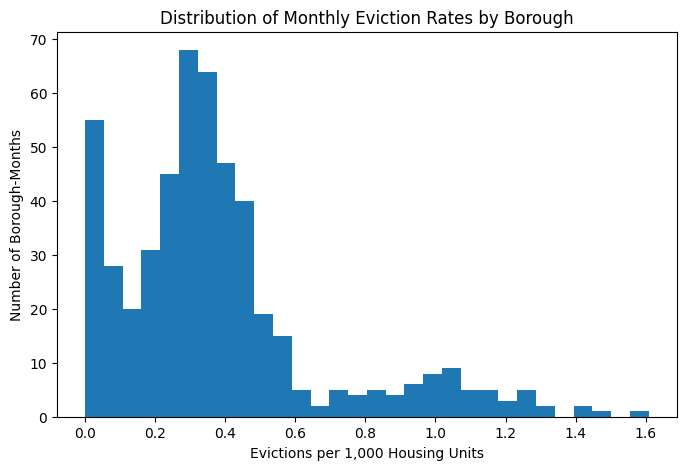

count   504.0000
mean      0.3807
std       0.2998
min       0.0010
25%       0.1961
50%       0.3265
75%       0.4583
max       1.6080
Name: evictions_per_1000_housing_units, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(monthly["evictions_per_1000_housing_units"], bins=30)
plt.title("Distribution of Monthly Eviction Rates by Borough")
plt.xlabel("Evictions per 1,000 Housing Units")
plt.ylabel("Number of Borough-Months")
plt.show()

print(monthly["evictions_per_1000_housing_units"].describe())

**Interpretation:**  
The distribution of eviction counts appears right-skewed, meaning most boroughs have relatively low eviction rates while a few have significantly higher values.This indicates that while most areas experience relatively low eviction rates, a small number of areas face extremely high eviction levels. This suggests inequality in housing stability and indicates that targeted interventions may be more effective than citywide policies

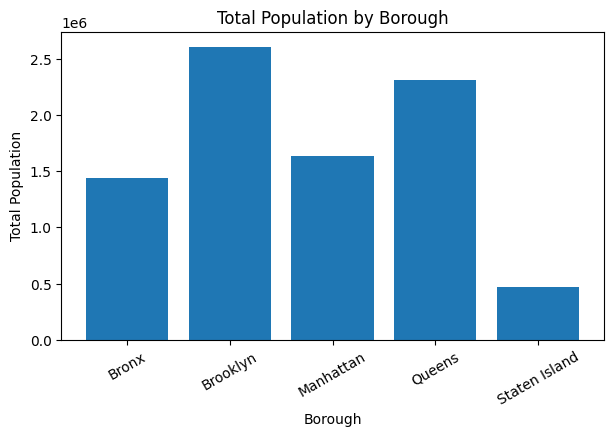

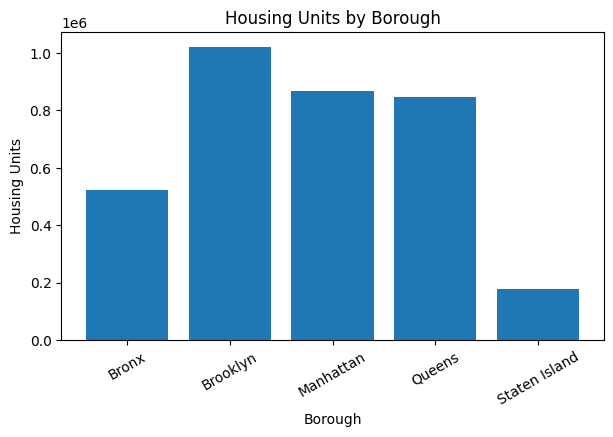

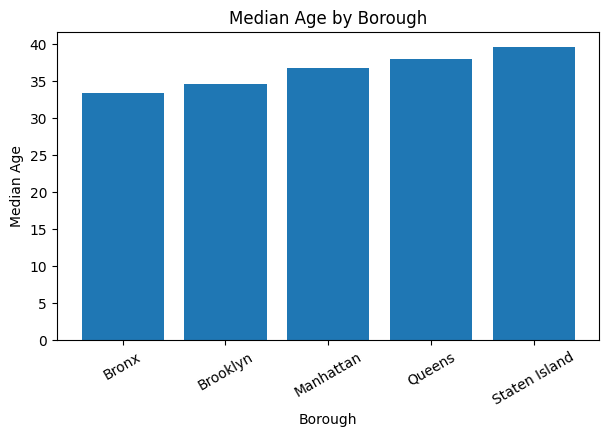

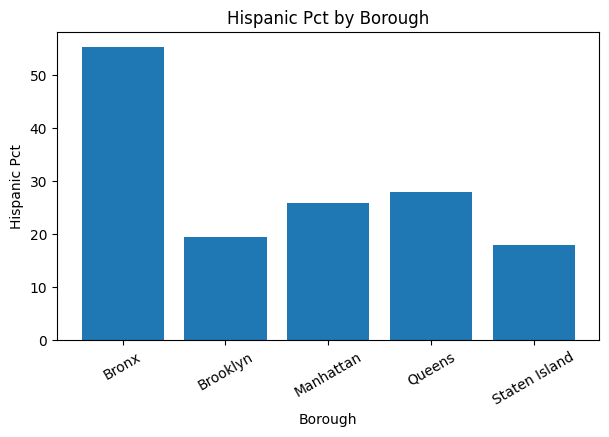

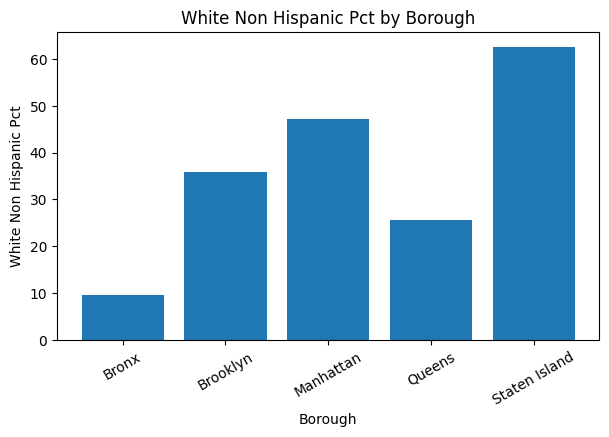

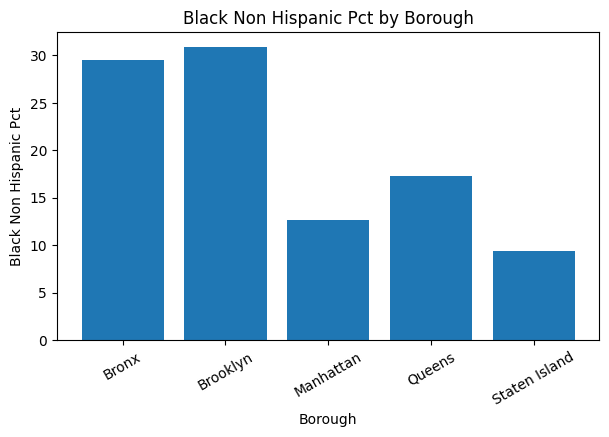

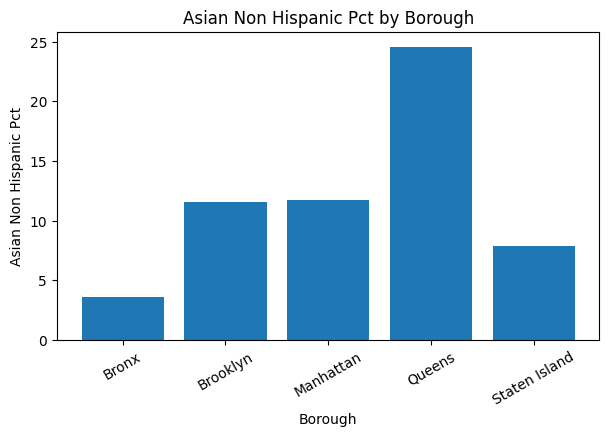

In [ ]:
demo_features = [
    "total_population",
    "housing_units",
    "median_age",
    "hispanic_pct",
    "white_non_hispanic_pct",
    "black_non_hispanic_pct",
    "asian_non_hispanic_pct"
]

for col in demo_features:
    plt.figure(figsize=(7, 4))
    plt.bar(demo["BOROUGH_CLEAN"], demo[col])
    plt.title(f"{col.replace('_', ' ').title()} by Borough")
    plt.xlabel("Borough")
    plt.ylabel(col.replace("_", " ").title())
    plt.xticks(rotation=30)
    plt.show()

**Interpretation:**  
The boroughs differ strongly in population size, housing stock, age, and racial/ethnic composition. This supports the project’s original idea that borough context may be related to eviction patterns. However, because there are only five boroughs, demographic relationships should be interpreted cautiously and not treated as proof of individual-level causation.


## 2.2 Correlation Matrix

The correlation matrix helps identify two things:

1. Which features have the strongest relationship with eviction rate  
2. Whether features are highly correlated with each other, which can create multicollinearity in simpler models


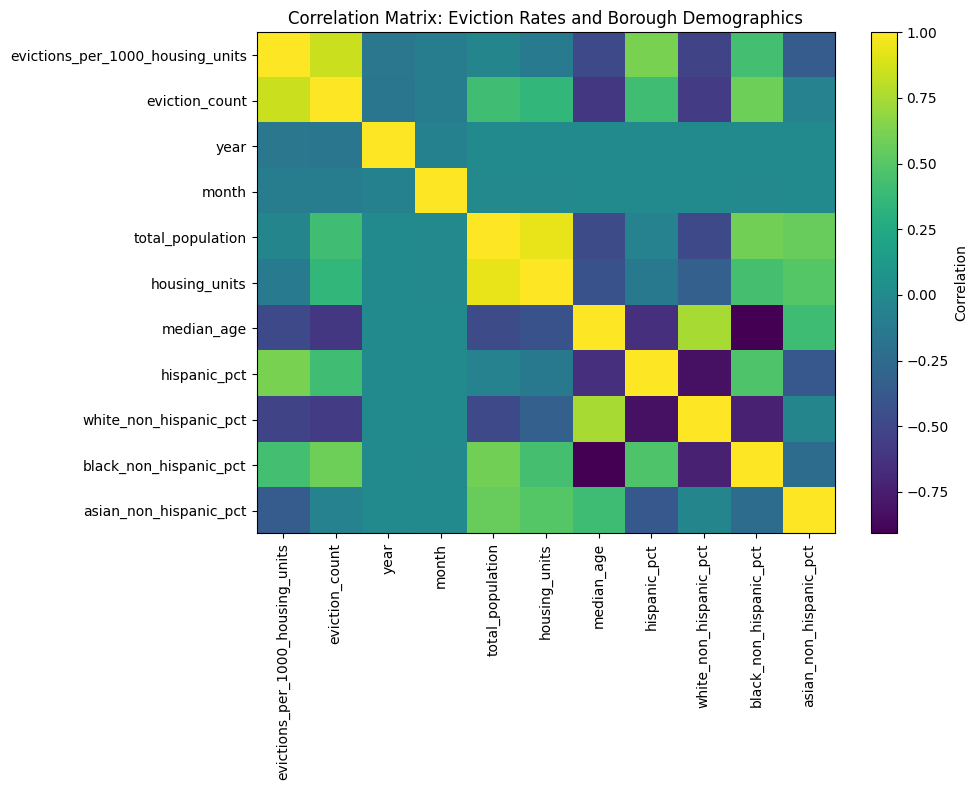

,evictions_per_1000_housing_units
evictions_per_1000_housing_units,1.0000
eviction_count,0.8443
hispanic_pct,0.6157
black_non_hispanic_pct,0.4307
total_population,-0.0360
month,-0.1031
housing_units,-0.1257
year,-0.1539
asian_non_hispanic_pct,-0.3554
median_age,-0.4873


In [ ]:
corr_cols = [
    "evictions_per_1000_housing_units",
    "eviction_count",
    "year",
    "month",
    "total_population",
    "housing_units",
    "median_age",
    "hispanic_pct",
    "white_non_hispanic_pct",
    "black_non_hispanic_pct",
    "asian_non_hispanic_pct"
]

corr = monthly[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix: Eviction Rates and Borough Demographics")
plt.tight_layout()
plt.show()

display(corr["evictions_per_1000_housing_units"].sort_values(ascending=False))

**Interpretation:**  
Among demographic variables, hispanic_pct (0.616) and black_non_hispanic_pct (0.431) show moderate positive correlations with eviction rates, suggesting that boroughs with higher proportions of these populations tend to experience higher eviction rates. In contrast, white_non_hispanic_pct (-0.520) shows a moderate negative correlation, indicating lower eviction rates in areas with higher white populations.

These patterns suggest that eviction risk is not evenly distributed across populations and may reflect underlying socioeconomic inequalities across boroughs.

Additionally, strong correlations between racial percentages indicate multicollinearity, since these variables are interdependent and sum to a shared population base. This is important for modeling, as including highly correlated features may distort model coefficients and reduce interpretability.


## 2.3 Bivariate Analysis

Now we compare eviction rates across boroughs and across time. This answers the question: **Where are eviction rates consistently higher, and did that change over time?**


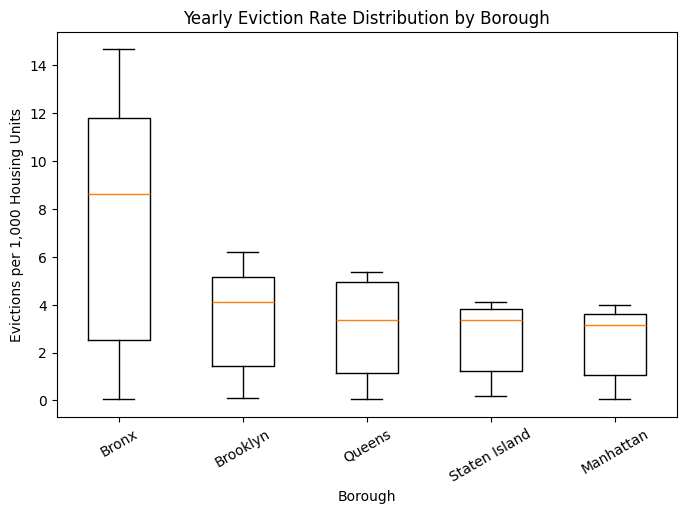

,mean,median,min,max
BOROUGH_CLEAN,,,,
Bronx,7.6524,8.6380,0.0555,14.6592
Brooklyn,3.4891,4.1116,0.0979,6.2197
Queens,3.0447,3.3820,0.0425,5.3597
Staten Island,2.5744,3.3594,0.1960,4.1097
Manhattan,2.4243,3.1339,0.0785,3.9809


In [ ]:
borough_order = (
    yearly.groupby("BOROUGH_CLEAN")["evictions_per_1000_housing_units"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(8, 5))
data_to_plot = [
    yearly.loc[yearly["BOROUGH_CLEAN"] == borough, "evictions_per_1000_housing_units"]
    for borough in borough_order
]
plt.boxplot(data_to_plot, labels=borough_order)
plt.title("Yearly Eviction Rate Distribution by Borough")
plt.xlabel("Borough")
plt.ylabel("Evictions per 1,000 Housing Units")
plt.xticks(rotation=30)
plt.show()

display(
    yearly.groupby("BOROUGH_CLEAN")["evictions_per_1000_housing_units"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

**Interpretation:**  
The Bronx has the highest average eviction rate of 7.65 per 1,000 housing units, significantly higher than all other boroughs, with a median of 8.64 and a maximum value reaching 14.66. In contrast, boroughs like Manhattan with a mean of 2.42 and Staten Island with a mean of 2.57 have substantially lower eviction rates.

This indicates that eviction vulnerability is not evenly distributed across New York City, but instead is highly concentrated in specific areas, particularly the Bronx. The wide range and higher variability in the Bronx also suggest that some neighborhoods within the borough experience extreme housing instability.


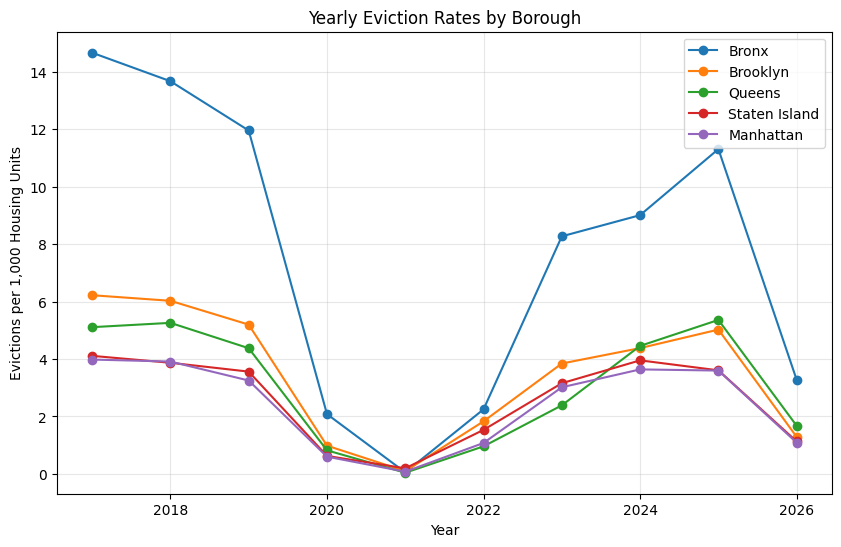

In [ ]:
plt.figure(figsize=(10, 6))
for borough in borough_order:
    temp = yearly[yearly["BOROUGH_CLEAN"] == borough]
    plt.plot(temp["year"], temp["evictions_per_1000_housing_units"], marker="o", label=borough)

plt.title("Yearly Eviction Rates by Borough")
plt.xlabel("Year")
plt.ylabel("Evictions per 1,000 Housing Units")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:**  
All boroughs exhibit a sharp decline in eviction rates between 2020 and 2021, with values dropping close to zero across the city. This pattern is consistent with pandemic-era eviction restrictions and court shutdowns, which temporarily suppressed eviction activity.

Following this period, eviction rates rise again across all boroughs. The Bronx consistently shows the highest eviction rates both before and after the pandemic, reaching significantly higher levels than other boroughs. In contrast, boroughs like Manhattan and Staten Island remain comparatively lower throughout the timeline.

This trend suggests that while external policy interventions can reduce evictions citywide, underlying structural differences between boroughs persist. As eviction rates rebound, historically high-risk areas such as the Bronx continue to experience elevated housing instability, indicating a need for targeted, long-term policy solutions rather than temporary measures.

# 3. Hypothesis Testing: Statistical Proof

We test whether average yearly eviction rates are the same across boroughs.

- Null hypothesis (H0): Evictions and housing demographics are not correlated.
- Alternative hypothesis (H1): Evictions and housing demographics are directly correlated.


In [ ]:
import statsmodels.api as sm

features = [
    "hispanic_pct",
    "black_non_hispanic_pct",
    "white_non_hispanic_pct",
    "asian_non_hispanic_pct",
    "median_age",
    "female_pct"
]

data = monthly[features + ["evictions_per_1000_housing_units"]].dropna()
X = data[features]
y = data["evictions_per_1000_housing_units"]

# Add constant (intercept)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     evictions_per_1000_housing_units   R-squared:                       0.431
Model:                                          OLS   Adj. R-squared:                  0.426
Method:                               Least Squares   F-statistic:                     94.48
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           8.80e-60
Time:                                      19:48:24   Log-Likelihood:                 34.507
No. Observations:                               504   AIC:                            -59.01
Df Residuals:                                   499   BIC:                            -37.90
Df Model:                                         4                                         
Covariance Type:                          nonrobust                                         
                             coef    std err          t      P>|t|    

**Milestone reporting interpretation:**  
To test the hypothesis that eviction rates are related to housing demographics, a multiple linear regression model was used with demographic variables as predictors.

The results show that all included demographic variables have p-values below 0.05, indicating statistically significant relationships with eviction rates. In particular, higher percentages of Hispanic and Black residents are associated with higher eviction rates, while higher percentages of White and Asian residents are associated with lower eviction rates. Median age and gender composition also show significant effects.

Since multiple demographic variables are statistically significant, we reject the null hypothesis that eviction rates are unrelated to housing demographics. This provides strong statistical evidence that demographic composition plays a meaningful role in eviction patterns across New York City.


# 4. Model Building: The Engine

This project uses supervised learning regression because the goal is to predict a numeric outcome of monthly evictions per 1,000 housing units

We use a Random Forest Regressor because it can capture nonlinear relationships and does not require strict linear assumptions. The model is evaluated using:

- RMSE: average prediction error in eviction-rate units  
- R²: how much variation in eviction rate the model explains


In [ ]:
features = [
    "total_population",
    "housing_units",
    "median_age",
    "female_pct",
    "hispanic_pct",
    "white_non_hispanic_pct",
    "black_non_hispanic_pct",
    "asian_non_hispanic_pct"
]

target = "evictions_per_1000_housing_units"

model_data = monthly.dropna(subset=features + [target]).copy()

X = model_data[features]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Regression model evaluation")
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

Regression model evaluation
RMSE: 0.2298
R²: 0.3983


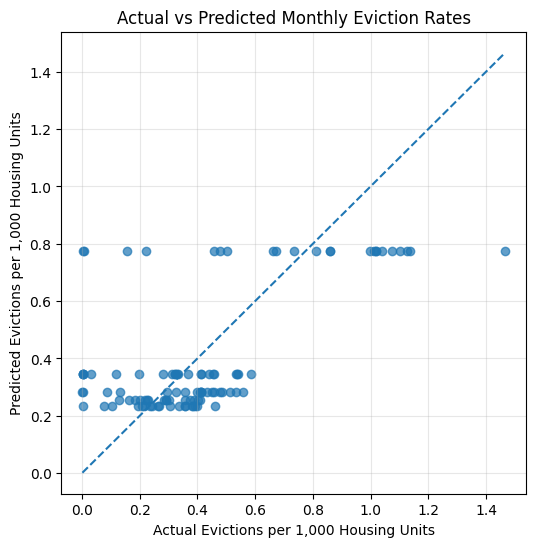

,actual,predicted
0,0.2929,0.2824
1,0.1570,0.7760
2,0.6738,0.7760
3,0.3808,0.2352
4,0.3660,0.3442
5,0.5324,0.3442
6,0.3337,0.3442
7,1.1256,0.7760
8,1.1007,0.7760
9,0.3863,0.2566


In [ ]:
results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": predictions
})

plt.figure(figsize=(6, 6))
plt.scatter(results["actual"], results["predicted"], alpha=0.7)
plt.plot([results["actual"].min(), results["actual"].max()],
         [results["actual"].min(), results["actual"].max()],
         linestyle="--")
plt.title("Actual vs Predicted Monthly Eviction Rates")
plt.xlabel("Actual Evictions per 1,000 Housing Units")
plt.ylabel("Predicted Evictions per 1,000 Housing Units")
plt.grid(True, alpha=0.3)
plt.show()

display(results.head(10))

**Interpretation:**  
The scatter plot shows a moderate relationship between predicted and actual eviction rates, indicating that the model captures some underlying patterns but does not fully explain the variation in eviction outcomes.

With an R² value of approximately 0.40, the results suggest that demographic and housing features account for a meaningful portion of eviction patterns, but a majority of the variation remains unexplained.

This indicates that while demographic characteristics are important predictors of eviction risk, they do not fully explain eviction patterns, and other factors such as economic conditions, policy changes, or local housing dynamics likely also play a significant role.

Therefore, the model is useful for identifying associations between demographics and eviction rates, but it should not be interpreted as a complete or causal explanation.


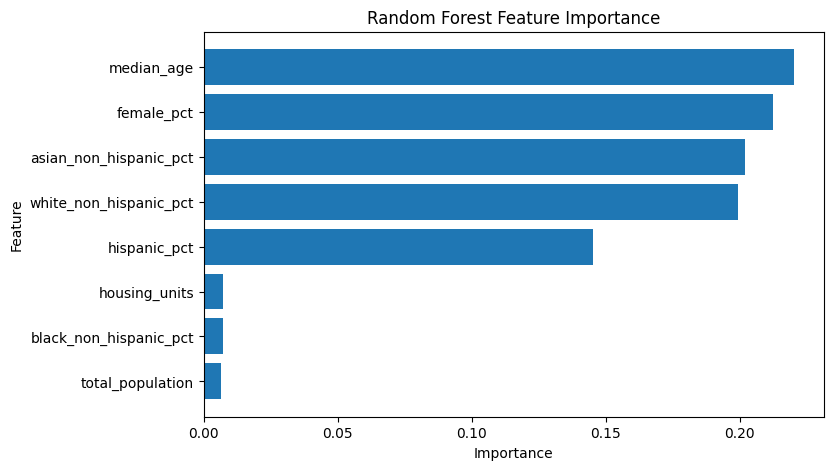

,feature,importance
0,median_age,0.2204
1,female_pct,0.2124
2,asian_non_hispanic_pct,0.2018
3,white_non_hispanic_pct,0.1995
4,hispanic_pct,0.1451
5,housing_units,0.0071
6,black_non_hispanic_pct,0.0070
7,total_population,0.0066


In [ ]:
feature_importance = (
    pd.Series(rf_model.feature_importances_, index=features)
    .sort_values(ascending=False)
    .reset_index()
)
feature_importance.columns = ["feature", "importance"]

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"][::-1], feature_importance["importance"][::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

display(feature_importance)

The feature importance results show that demographic characteristics are key predictors of eviction rates. In particular, median age and the percentage of female residents are the most influential variables in the model, followed closely by racial composition variables such as asian_non_hispanic_pct and white_non_hispanic_pct.

These results suggest that population composition plays a meaningful role in shaping eviction patterns. The importance of multiple demographic variables also supports the earlier statistical findings that eviction rates are associated with demographic characteristics rather than a single factor.

In contrast, variables such as total population, housing units, and black_non_hispanic_pct have relatively low importance in the model. This indicates that overall population size or scale alone is not a strong predictor of eviction rates, and that eviction risk is more closely tied to specific demographic characteristics than to the size of a borough.

# 5. Knowledge Discovery: The “Aha!” Moment

#What did we learn?

The most important finding is that eviction patterns are not evenly distributed across New York City and are strongly associated with demographic composition. The Bronx consistently shows the highest eviction rates per 1,000 housing units, highlighting significant geographic inequality in housing stability.

The statistical analysis and regression results demonstrate that multiple demographic factors including racial composition, median age, and gender distribution have statistically significant relationships with eviction rates. This indicates that eviction risk is meaningfully linked to the demographic characteristics of a borough.

#What was not obvious at first?

One key insight is that raw eviction counts can be misleading, as larger boroughs naturally have more residents and housing units. Standardizing eviction rates per 1,000 housing units provides a more accurate comparison and reveals that certain areas, like the Bronx, face disproportionately high eviction pressure even after adjusting for population size.

Another important finding is that while demographic variables are significant predictors, they do not fully explain eviction patterns. The model explains only a portion of the variation in eviction rates, suggesting that external factors such as economic conditions or housing policies also play a major role.

#Actionable insight

These findings suggest that housing policy should prioritize eviction prevention efforts in areas with consistently high eviction rates, particularly in vulnerable boroughs like the Bronx. Targeted interventions could include expanding tenant legal assistance, increasing rental support programs, and focusing on early intervention before eviction filings escalate.

More broadly, policies should consider the demographic composition of neighborhoods when allocating resources, as eviction risk is closely associated with underlying population characteristics rather than just overall population size.

#Limitation

This analysis is based on borough level demographic data, which limits the ability to capture variation within boroughs. As a result, the model identifies the sum total associations of the populace but cannot determine individual level risk or establish any form of causation.

Future work could improve accuracy by using census or neighborhood level demographics, to better understand localized eviction patterns and provide more accurate policy recommendations.